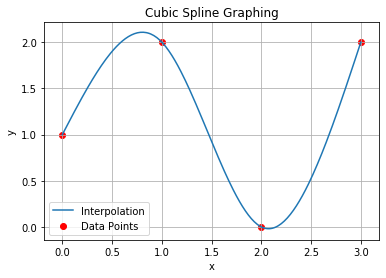

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def evaluate_spline(x, y, M, h, xeval):
    for i in range(len(x) - 1):
        if x[i] <= xeval <= x[i + 1]:
            term1 = M[i] * (x[i + 1] - xeval)**3 / (6 * h[i])
            term2 = M[i + 1] * (xeval - x[i])**3 / (6 * h[i])
            term3 = (y[i] / h[i] - M[i] * h[i] / 6) * (x[i + 1] - xeval)
            term4 = (y[i + 1] / h[i] - M[i + 1] * h[i] / 6) * (xeval - x[i])
            return term1 + term2 + term3 + term4

def thomas(A, B, C, D):
    n = len(D)
    for i in range(1, n):
        w = A[i] / B[i - 1]
        B[i] = B[i] - w * C[i - 1]
        D[i] = D[i] - w * D[i - 1]

    M = np.zeros(n)
    M[n - 1] = D[n - 1] / B[n - 1]

    for i in range(n - 2, -1, -1):
        M[i] = (D[i] - C[i] * M[i + 1]) / B[i]

    return M

x = np.array([0, 1, 2, 3])
y = np.array([1, 2, 0, 2])
n = len(x)
h = np.zeros(n - 1)
for i in range(n - 1):
    h[i] = x[i + 1] - x[i]

A = np.zeros(n)
B = np.zeros(n)
C = np.zeros(n)
D = np.zeros(n)

B[0] = 1
B[n - 1] = 1
D[0] = 0
D[n - 1] = 0

for i in range(1, n - 1):
    A[i] = h[i - 1]
    B[i] = 2 * (h[i - 1] + h[i])
    C[i] = h[i]
    D[i] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

M = thomas(A, B, C, D)

xvals = np.linspace(x[0], x[-1], 200)
yvals = []

for val in xvals:
    yvals.append(evaluate_spline(x, y, M, h, val))

plt.plot(xvals, yvals, label = 'Interpolation')
plt.scatter(x, y, color = 'red', label = 'Data Points')
plt.title('Cubic Spline Graphing')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()